# Репутация и финансовые результаты: репликация регрессий

Реплицируем финансовый блок `index_0_finance.ipynb` (ячейки 10–14) с новой
образовательной компонентой и готовыми CSV. Две выборки: **все менеджеры** и **CEO**.

Три основных представления репутации:

- образование и экспертиза (`expertise_score`) отдельно;
- общий индекс с равными весами и общий индекс CRITIC из `index_eda.ipynb`;
- все пять компонент одновременно как отдельные регрессоры.

Дополнительно оцениваем каждую компоненту по отдельности, сравниваем модели
на общей выборке и повторяем эксперимент CatBoost–SHAP из конца исходного ноутбука.
Ни персональные данные, ни внутренние образовательные веса здесь не пересчитываются.

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import platform
import numpy as np
import pandas as pd
from scipy import stats
import scipy
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'index_data.csv').exists() and (p / 'utils').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Запустите ноутбук из каталога проекта')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from utils.index_components import SCORE_COLUMNS
from utils.index_regression import CONTROLS, OUTCOMES, prepare_finance, fit_ols, bh_adjust, regression_specs

COMPONENTS = list(SCORE_COLUMNS)
SAMPLE_LABELS = {'all_managers': 'Все менеджеры', 'ceo': 'CEO'}
LABELS = {'expertise_score': 'Образование', 'index_equal': 'Индекс: равные веса', 'index_critic': 'Индекс: CRITIC',
          'media_score': 'Медиа', 'awards_score': 'Награды', 'face_score': 'Лица', 'communication_score': 'Коммуникация'}
OUTCOME_LABELS = {'roa_2025': 'ROA 2025', 'stock_return_2025': 'Доходность акций 2025'}
FINANCE_FILE = ROOT / 'Companies_MOEXBMI_2024_2025.xlsx'
if not FINANCE_FILE.exists():
    FINANCE_FILE = ROOT / 'Companiex_MOEXBMI_2024_2025.xlsx'
INDEX_FILES = {'all_managers': ROOT / 'index_data.csv', 'ceo': ROOT / 'index_data_ceo.csv'}
EDA_FILES = {sample: ROOT / 'results/index_eda' / f'{sample}_indices.csv' for sample in INDEX_FILES}
WEIGHT_FILES = {sample: ROOT / 'results/index_eda' / f'{sample}_point_weights.csv' for sample in INDEX_FILES}
OUT, FIGS = ROOT / 'results/index_regression', ROOT / 'figs'
OUT.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
RUN_CATBOOST = True
SEED = 42
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10, 'pdf.fonttype': 42,
                     'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 110})
pd.set_option('display.max_columns', 25)

def save_table(frame, name, index=True):
    frame.to_csv(OUT / (name + '.csv'), index=index, encoding='utf-8-sig')

def finish_figure(fig, name):
    fig.tight_layout()
    fig.savefig(FIGS / ('index_regression_' + name + '.pdf'), bbox_inches='tight')
    plt.show()
    plt.close(fig)

## Что переносится из исходного ноутбука

Зависимые переменные: ROA и доходность акций за 2025 год; значения в Excel уже
в долях единицы. Контроли: соответствующий результат за 2024 год, натуральный
логарифм активов 2024, возраст компании, финансовый рычаг, ОС/активы и госучастие 2024.
Возраст берётся как записан в файле; отдельного возраста на конец 2024 года там нет.

| Код | Спецификация |
| --- | --- |
| M1 | Только исследуемый показатель / блок компонент |
| M2 | M1 + зависимая переменная за 2024 год |
| M3 | M2 + финансовые контроли (основная) |
| M4 | M3 + отраслевые dummy; редкие отрасли объединены |
| M5 | Как M3, но логарифм сотрудников вместо логарифма активов |
| C2024 | Одновременная связь с результатом 2024 + контроли |
| W2025 | Как M3, с винзоризацией результата 2025 на 1-м/99-м процентилях |

Все индексы и компоненты делятся на 10. Коэффициент ×100 — изменение результата
в **процентных пунктах на 10 баллов** индекса/компоненты. В совместной модели это
связь при фиксированных остальных компонентах. Общий индекс и его составляющие
не включаются одновременно: между ними была бы точная линейная зависимость.

[HC3](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.HC3_se.html)
учитывает гетероскедастичность. Как в основной ячейке исходника, p-value и интервалы
используют t-распределение с N−rank степенями свободы; это явно отличается от
нормального приближения по умолчанию в поздней ячейке `statsmodels`.
Расчёт OLS сделан через SVD для численной устойчивости; формулы HC3 и PRESS сохранены.

Изменения относительно старого расчёта: используем новые CSV и веса; сохраняем
пропуски; HEAD и HNFG остаются разными компаниями (ошибка старого алиаса уже устранена).
Постоянные регрессоры явно отмечаются как неидентифицируемые. При рычаге h=1
HC3 и PRESS не определены: вместо искусственного обрезания знаменателя выводится NaN.

In [2]:
finance = prepare_finance(pd.read_excel(FINANCE_FILE))
save_table(finance, 'finance_prepared')
datasets, merge_audits, winsor_audits = {}, [], []
for sample, path in INDEX_FILES.items():
    components = pd.read_csv(path, encoding='utf-8-sig').set_index('ticker').sort_index()
    if not components.index.is_unique or components.index.isna().any():
        raise ValueError('Пустые/повторные тикеры в CSV компонент')
    if list(components) != COMPONENTS:
        raise ValueError('Неожиданный набор компонент')
    if not EDA_FILES[sample].exists():
        raise FileNotFoundError('Сначала выполните notebooks/index_eda.ipynb: нужны CSV готовых общих индексов')
    eda = pd.read_csv(EDA_FILES[sample], encoding='utf-8-sig').set_index('ticker').sort_index()
    pd.testing.assert_frame_equal(components, eda[COMPONENTS], check_dtype=False, atol=1e-10, rtol=1e-10)
    weights = pd.read_csv(WEIGHT_FILES[sample], index_col=0)
    complete = components.dropna()
    for method in ['equal', 'critic']:
        np.testing.assert_allclose(weights[method].sum(), 1)
        np.testing.assert_allclose(complete.dot(weights.loc[COMPONENTS, method]), eda.loc[complete.index, f'index_{method}'], atol=1e-10)
        assert eda.loc[components.isna().any(axis=1), f'index_{method}'].isna().all()
    reputation = components.join(eda[['index_equal', 'index_critic']], validate='one_to_one')
    merged = reputation.join(finance, how='inner', validate='one_to_one')
    counts = merged.industry_raw.value_counts()
    merged['industry_group'] = merged.industry_raw.where(merged.industry_raw.map(counts).ge(3), 'Прочие')
    merged.loc[merged.industry_raw.isna(), 'industry_group'] = 'Не указана'
    for col in [*COMPONENTS, 'index_equal', 'index_critic']:
        merged[col + '_10'] = merged[col] / 10
    for outcome in OUTCOMES:
        lo, hi = merged[outcome].quantile([.01, .99])
        merged[outcome + '_w'] = merged[outcome].clip(lo, hi)
        winsor_audits.append({'sample': sample, 'outcome': outcome, 'q01': lo, 'q99': hi,
            'n_observed': merged[outcome].count(), 'n_clipped': int(((merged[outcome] < lo) | (merged[outcome] > hi)).sum())})
    datasets[sample] = merged
    audit = pd.DataFrame(index=reputation.index.union(finance.index))
    audit['in_index'] = audit.index.isin(reputation.index)
    audit['in_finance'] = audit.index.isin(finance.index)
    save_table(audit, f'{sample}_ticker_merge_audit')
    save_table(merged, f'{sample}_merged_index_finance')
    merge_audits.append({'sample': sample, 'index_companies': len(reputation), 'finance_companies': len(finance),
        'matched': len(merged), 'education_observed': merged.expertise_score.count(),
        'total_index_observed': merged.index_critic.count(),
        'index_only': ', '.join(reputation.index.difference(finance.index)),
        'finance_only': ', '.join(finance.index.difference(reputation.index))})
merge_audit = pd.DataFrame(merge_audits)
display(merge_audit)
save_table(merge_audit, 'merge_audit', index=False)
save_table(pd.DataFrame(winsor_audits), 'winsorization_audit', index=False)

,sample,index_companies,finance_companies,matched,education_observed,total_index_observed,index_only,finance_only
0,all_managers,110,109,109,109,64,NVTK,
1,ceo,110,109,109,104,28,NVTK,


## Данные и доступность

Объединение выполняется только по тикеру. Образование не требует наличия медиа,
фото или коммуникации; поэтому его отдельные регрессии могут иметь большую выборку.
Для общего индекса и совместной модели нужны все пять компонент.

В каждой спецификации удаляются строки с пропусками именно её переменных;
финансовые пропуски не заполняются нулём. Отрасли с менее чем тремя компаниями
в объединённой исходной таблице попадают в «Прочие», как в исходнике.
Контроль отрасли может оказаться представлен одной компанией уже после удаления
пропусков; это отмечается в диагностике HC3/PRESS.
Винзоризация относится только к исходу, а не к шкалам индекса.
Доходности |r| >80% сохраняются для проверки корпоративных действий, но автоматически
не удаляются. Изменения доходности, CAR и альфа не подменяют исходные зависимые переменные.

In [3]:
for sample, data in datasets.items():
    columns = [*COMPONENTS, 'index_equal', 'index_critic', *OUTCOMES, *OUTCOMES.values(), *CONTROLS, 'log_employees_2024']
    summary = data[columns].describe(percentiles=[.01, .5, .99]).T
    summary['missing'] = data[columns].isna().sum()
    save_table(summary, f'{sample}_descriptive')
    display(Markdown('### ' + SAMPLE_LABELS[sample]))
    display(summary[['count', 'mean', 'std', 'min', '50%', 'max', 'missing']].round(3))
    extreme = data.loc[data[['stock_return_2024', 'stock_return_2025']].abs().gt(.8).any(axis=1),
                       ['company_finance', 'stock_return_2024', 'stock_return_2025']]
    save_table(extreme, f'{sample}_extreme_returns')
    display(extreme)
correlation_rows = []
for sample, data in datasets.items():
    for predictor in [*COMPONENTS, 'index_equal', 'index_critic']:
        for outcome in [*OUTCOMES, *OUTCOMES.values()]:
            pair = data[[predictor, outcome]].dropna()
            for method, function in [('Pearson', stats.pearsonr), ('Spearman', stats.spearmanr)]:
                defined = len(pair) >= 3 and pair.nunique().gt(1).all()
                rho, p = function(pair[predictor], pair[outcome]) if defined else (np.nan, np.nan)
                correlation_rows.append({'sample': sample, 'predictor': predictor, 'outcome': outcome,
                                         'method': method, 'n': len(pair), 'correlation': rho, 'p_value': p})
correlations = pd.DataFrame(correlation_rows)
correlations['q_value_bh'] = correlations.groupby(['sample', 'method']).p_value.transform(bh_adjust)
save_table(correlations, 'correlations_fdr', index=False)
display(correlations.query("predictor == 'expertise_score' and method == 'Spearman'").round(4))

### Все менеджеры

,count,mean,std,min,50%,max,missing
media_score,108.0,56.701,7.232,33.717,57.534,73.451,1
awards_score,108.0,8.084,11.875,0.000,4.466,72.170,1
expertise_score,109.0,39.189,12.047,12.453,40.102,72.542,0
face_score,79.0,49.585,6.495,33.322,50.379,66.743,30
communication_score,82.0,94.512,20.796,0.000,100.000,100.000,27
index_equal,64.0,50.097,5.443,25.005,50.458,68.098,45
index_critic,64.0,53.136,6.587,19.086,53.209,73.105,45
roa_2025,101.0,0.056,0.159,-0.660,0.046,0.714,8
stock_return_2025,103.0,-0.002,0.379,-1.000,-0.070,1.740,6
roa_2024,102.0,0.089,0.144,-0.286,0.052,0.998,7


,company_finance,stock_return_2024,stock_return_2025
ticker,,,
BELU,"ПАО ""НоваБев Групп""",-0.90,-0.14
BSPB,"ПАО ""Банк ""Санкт-Петербург""",0.91,-0.03
MRKC,"ПАО ""РОССЕТИ ЦЕНТР""",-0.04,0.95
MRKP,"ПАО ""РОССЕТИ ЦЕНТР И ПРИВОЛЖЬЕ""",0.25,0.83
MRKV,"ПАО ""РОССЕТИ ВОЛГА""",0.28,1.74
PLZL,"ПАО ""ПОЛЮС""",0.31,-0.82
QIWI,КИВИ ПиЭлСи,-0.69,-1.00
SFIN,"ПАО ""ЭсЭфАй""",2.11,0.48
SPBE,"ПАО ""СПБ Биржа""",0.60,1.08


### CEO

,count,mean,std,min,50%,max,missing
media_score,77.0,61.087,7.885,39.370,60.780,82.473,32
awards_score,90.0,11.281,21.348,0.000,0.000,75.630,19
expertise_score,104.0,40.293,16.439,7.571,42.929,80.708,5
face_score,43.0,51.315,8.209,29.960,52.660,64.523,66
communication_score,82.0,94.512,20.796,0.000,100.000,100.000,27
index_equal,28.0,53.258,4.986,43.092,53.068,64.177,81
index_critic,28.0,33.170,8.197,18.881,31.728,53.971,81
roa_2025,101.0,0.056,0.159,-0.660,0.046,0.714,8
stock_return_2025,103.0,-0.002,0.379,-1.000,-0.070,1.740,6
roa_2024,102.0,0.089,0.144,-0.286,0.052,0.998,7


,company_finance,stock_return_2024,stock_return_2025
ticker,,,
BELU,"ПАО ""НоваБев Групп""",-0.90,-0.14
BSPB,"ПАО ""Банк ""Санкт-Петербург""",0.91,-0.03
MRKC,"ПАО ""РОССЕТИ ЦЕНТР""",-0.04,0.95
MRKP,"ПАО ""РОССЕТИ ЦЕНТР И ПРИВОЛЖЬЕ""",0.25,0.83
MRKV,"ПАО ""РОССЕТИ ВОЛГА""",0.28,1.74
PLZL,"ПАО ""ПОЛЮС""",0.31,-0.82
QIWI,КИВИ ПиЭлСи,-0.69,-1.00
SFIN,"ПАО ""ЭсЭфАй""",2.11,0.48
SPBE,"ПАО ""СПБ Биржа""",0.60,1.08


,sample,predictor,outcome,method,n,correlation,p_value,q_value_bh
17,all_managers,expertise_score,roa_2025,Spearman,101,-0.0455,0.6514,0.7327
19,all_managers,expertise_score,stock_return_2025,Spearman,103,-0.1732,0.0801,0.3739
21,all_managers,expertise_score,roa_2024,Spearman,102,-0.0190,0.8498,0.8813
23,all_managers,expertise_score,stock_return_2024,Spearman,92,0.0743,0.4815,0.7327
73,ceo,expertise_score,roa_2025,Spearman,97,-0.0096,0.9257,0.9600
75,ceo,expertise_score,stock_return_2025,Spearman,98,-0.1108,0.2774,0.8899
77,ceo,expertise_score,roa_2024,Spearman,97,0.0560,0.5862,0.8899
79,ceo,expertise_score,stock_return_2024,Spearman,87,-0.0580,0.5935,0.8899


## Регрессии: образование, общие индексы, компоненты совместно

Результаты сохраняются для всех спецификаций и всех коэффициентов, включая
контроли и отраслевые dummy. Отдельный аудит содержит состав каждой выборки,
причины исключения компаний, число параметров, максимальный рычаг и статус оценки.
Недостаток наблюдений или коллинеарность не приводит к молчаливому изменению модели.
Основные таблицы ниже показывают M3. Положительный коэффициент означает положительную
условную связь, а не установленный причинный эффект.

In [4]:
model_rows, coefficient_rows, membership_rows, observation_rows = [], [], [], []
fits = {}

def run_model(sample, data, outcome, block, specification, predictors, categorical=(), focal=(), family='main'):
    model_id = f'{sample}__{outcome}__{block}__{specification}__{family}'
    required = [outcome, *predictors, *categorical]
    missing = data[required].isna()
    for ticker, row in missing.iterrows():
        membership_rows.append({'model_id': model_id, 'ticker': ticker, 'included': not row.any(),
                                'missing_variables': ', '.join(row.index[row])})
    meta = {'model_id': model_id, 'sample': sample, 'outcome': outcome, 'block': block,
            'specification': specification, 'family': family,
            'formula': outcome + ' ~ ' + ' + '.join([*predictors, *[f'C({c})' for c in categorical]])}
    try:
        fit = fit_ols(data, outcome, predictors, categorical)
    except ValueError as exc:
        model_rows.append({**meta, 'status': 'not_estimable', 'reason': str(exc),
                           'n': int((~missing.any(axis=1)).sum())})
        return None
    fits[model_id] = fit
    model_rows.append({**meta, 'status': fit['inference_status'], 'reason': '',
                      **{key: fit[key] for key in ['n', 'rank', 'df_resid', 'r2', 'adj_r2', 'sse', 'cv_r2',
                          'cv_rmse', 'max_leverage', 'condition_number']},
                      'dropped_constant': ', '.join(fit['dropped_constant'])})
    table = fit['table'].copy()
    for term in focal:
        if term not in set(table.term):
            table = pd.concat([table, pd.DataFrame([{'term': term}])], ignore_index=True)
    for row in table.to_dict('records'):
        is_focal = row['term'] in focal
        coefficient_rows.append({**meta, **row, 'n': fit['n'], 'is_focal': is_focal,
            'term_status': 'constant_not_identified' if row['term'] in fit['dropped_constant'] else fit['inference_status'],
            'effect_pp_per_10_points': row.get('coef', np.nan) * 100 if is_focal else np.nan,
            'se_pp_hc3': row.get('se_hc3', np.nan) * 100 if is_focal else np.nan,
            'ci_low_pp': row.get('ci_low', np.nan) * 100 if is_focal else np.nan,
            'ci_high_pp': row.get('ci_high', np.nan) * 100 if is_focal else np.nan})
    obs = fit['observations'].reset_index()
    obs['model_id'] = model_id
    observation_rows.extend(obs.to_dict('records'))
    return fit

BLOCKS = {'education': ['expertise_score_10'], 'index_equal': ['index_equal_10'],
          'index_critic': ['index_critic_10'], 'components_joint': [c + '_10' for c in COMPONENTS]}
for sample, data in datasets.items():
    for outcome, lag in OUTCOMES.items():
        for block, terms in BLOCKS.items():
            for dependent, specification, predictors, categories in regression_specs(outcome, lag, terms):
                run_model(sample, data, dependent, block, specification, predictors, categories, terms)

coefficients = pd.DataFrame(coefficient_rows)
primary = coefficients.query("family == 'main' and specification == 'M3' and is_focal").copy()
primary['fdr_family'] = np.where(primary.block.eq('components_joint'), 'joint_components_2_outcomes', 'education_and_indices_2_outcomes')
primary['q_value_bh'] = primary.groupby(['sample', 'fdr_family']).p_value.transform(bh_adjust)
save_table(primary, 'primary_M3_fdr', index=False)
for sample in datasets:
    display(Markdown('### ' + SAMPLE_LABELS[sample]))
    display(primary[primary['sample'].eq(sample)][['outcome', 'block', 'term', 'n', 'effect_pp_per_10_points',
        'ci_low_pp', 'ci_high_pp', 'p_value', 'q_value_bh', 'term_status']].round(4))

### Все менеджеры

,outcome,block,term,n,effect_pp_per_10_points,ci_low_pp,ci_high_pp,p_value,q_value_bh,term_status
6,roa_2025,education,expertise_score_10,93,1.2594,-0.8534,3.3722,0.2393,0.4785,ok
57,roa_2025,index_equal,index_equal_10,56,-2.7545,-6.6276,1.1187,0.1592,0.4777,ok
106,roa_2025,index_critic,index_critic_10,56,-2.4502,-5.5659,0.6655,0.1204,0.4777,ok
163,roa_2025,components_joint,media_score_10,56,0.6438,NaN,NaN,NaN,NaN,undefined_hc3_and_press_leverage_one
164,roa_2025,components_joint,awards_score_10,56,-1.7492,NaN,NaN,NaN,NaN,undefined_hc3_and_press_leverage_one
165,roa_2025,components_joint,expertise_score_10,56,0.9732,NaN,NaN,NaN,NaN,undefined_hc3_and_press_leverage_one
166,roa_2025,components_joint,face_score_10,56,-2.3191,NaN,NaN,NaN,NaN,undefined_hc3_and_press_leverage_one
167,roa_2025,components_joint,communication_score_10,56,-1.0661,NaN,NaN,NaN,NaN,undefined_hc3_and_press_leverage_one
232,stock_return_2025,education,expertise_score_10,77,1.2303,-4.8056,7.2661,0.6855,0.6855,ok
283,stock_return_2025,index_equal,index_equal_10,43,6.3190,-14.6532,27.2912,0.5447,0.6536,ok


### CEO

,outcome,block,term,n,effect_pp_per_10_points,ci_low_pp,ci_high_pp,p_value,q_value_bh,term_status
455,roa_2025,education,expertise_score_10,90,0.9057,-0.8653,2.6766,0.3120,0.7186,ok
506,roa_2025,index_equal,index_equal_10,27,-3.6835,-10.5721,3.2051,0.2770,0.7186,ok
555,roa_2025,index_critic,index_critic_10,27,-1.7512,-6.8273,3.3249,0.4790,0.7186,ok
612,roa_2025,components_joint,media_score_10,27,-0.5702,-3.8115,2.6712,0.7141,0.9577,ok
613,roa_2025,components_joint,awards_score_10,27,-0.4529,-3.2376,2.3318,0.7348,0.9577,ok
614,roa_2025,components_joint,expertise_score_10,27,0.0654,-2.5065,2.6374,0.9577,0.9577,ok
615,roa_2025,components_joint,face_score_10,27,-2.8203,-6.4620,0.8214,0.1201,0.4806,ok
622,roa_2025,components_joint,communication_score_10,27,NaN,NaN,NaN,NaN,NaN,constant_not_identified
681,stock_return_2025,education,expertise_score_10,74,1.9847,-2.5143,6.4838,0.3816,0.7186,ok
732,stock_return_2025,index_equal,index_equal_10,20,4.6586,-78.5286,87.8458,0.9049,0.9049,ok


## Каждая компонента отдельно

Как в исходнике, оцениваем пять отдельных M3-регрессий для каждого исхода.
Это не то же самое, что совместная модель: здесь другие репутационные компоненты
не входят в контроли, и состав компаний может быть шире.
Benjamini–Hochberg применяется к семье 5 компонент × 2 исхода отдельно для каждой
выборки. В основной таблице выше свои две семьи: 3 одиночных показателя × 2 исхода
и 5 совместных коэффициентов × 2 исхода. Неидентифицируемые коэффициенты не тестируются.
Коррекции по всем альтернативным спецификациям M1–M5 одновременно здесь нет.

In [5]:
for sample, data in datasets.items():
    for outcome, lag in OUTCOMES.items():
        for component in COMPONENTS:
            term = component + '_10'
            run_model(sample, data, outcome, component, 'M3', [term, lag, *CONTROLS],
                      focal=[term], family='individual_components')
coefficients = pd.DataFrame(coefficient_rows)
individual = coefficients.query("family == 'individual_components' and is_focal").copy()
individual['q_value_bh'] = individual.groupby('sample').p_value.transform(bh_adjust)
save_table(individual, 'individual_components_fdr', index=False)
display(individual[['sample', 'outcome', 'block', 'n', 'effect_pp_per_10_points', 'ci_low_pp', 'ci_high_pp',
                    'p_value', 'q_value_bh', 'term_status']].round(4))

,sample,outcome,block,n,effect_pp_per_10_points,ci_low_pp,ci_high_pp,p_value,q_value_bh,term_status
881,all_managers,roa_2025,media_score,93,0.3590,-2.6669,3.3849,0.8141,0.8141,ok
889,all_managers,roa_2025,awards_score,93,-0.5088,-2.9874,1.9698,0.6842,0.8141,ok
897,all_managers,roa_2025,expertise_score,93,1.2594,-0.8534,3.3722,0.2393,0.7611,ok
905,all_managers,roa_2025,face_score,67,-0.9845,-3.6136,1.6445,0.4566,0.7611,ok
913,all_managers,roa_2025,communication_score,73,-0.2051,-1.4212,1.0109,0.7373,0.8141,ok
921,all_managers,stock_return_2025,media_score,77,-11.3594,-21.9845,-0.7344,0.0365,0.3650,ok
929,all_managers,stock_return_2025,awards_score,77,3.4150,-3.2289,10.0590,0.3087,0.7611,ok
937,all_managers,stock_return_2025,expertise_score,77,1.2303,-4.8056,7.2661,0.6855,0.8141,ok
945,all_managers,stock_return_2025,face_score,54,5.7855,-9.4990,21.0699,0.4500,0.7611,ok
953,all_managers,stock_return_2025,communication_score,57,1.9573,-1.7763,5.6909,0.2973,0.7611,ok


## Сравнение объясняющей и предсказательной способности на общей выборке

Для каждого исхода и варианта менеджмента берём одинаковые полные строки для всех
пяти моделей: контроли; контроли + образование; + равный индекс; + CRITIC;
+ пять компонент. Повторяем сравнение без отраслевых dummy и с ними, как в исходнике.
Частный R² = (SSE контролей − SSE расширенной модели) / SSE контролей.

LOOCV считается по PRESS = e/(1−h). Это оценка регрессии **при фиксированных
готовых индексах**: она не переоценивает внутренние образовательные веса и внешние
CRITIC-веса при исключении компании. Это не проверка всего процесса построения
индекса на новых данных. Винзоризированные исходы также используют фиксированные
границы. При h=1 предсказание для исключённого наблюдения не идентифицировано;
соответствующий LOOCV оставляется пустым.

In [6]:
comparison_rows = []
COMPARISON = {'controls': [], **BLOCKS}
for sample, data in datasets.items():
    for outcome, lag in OUTCOMES.items():
        required = [outcome, lag, *CONTROLS, 'industry_group', *[c + '_10' for c in COMPONENTS], 'index_equal_10', 'index_critic_10']
        common = data.dropna(subset=required)
        save_table(common, f'{sample}_{outcome}_common_sample')
        for industry in [False, True]:
            specification = 'common_industry' if industry else 'common_no_industry'
            base = None
            for block, terms in COMPARISON.items():
                fit = run_model(sample, common, outcome, block, specification,
                                [lag, *CONTROLS, *terms], ['industry_group'] if industry else [],
                                terms, family='comparison')
                if block == 'controls':
                    base = fit
                row = {'sample': sample, 'outcome': outcome, 'block': block, 'specification': specification, 'n_common': len(common)}
                if fit is not None:
                    row.update({key: fit[key] for key in ['n', 'r2', 'adj_r2', 'cv_r2', 'cv_rmse', 'inference_status']})
                    row['partial_r2_vs_controls'] = (base['sse'] - fit['sse']) / base['sse'] if base and base['sse'] > 0 else np.nan
                comparison_rows.append(row)
comparison = pd.DataFrame(comparison_rows)
save_table(comparison, 'model_comparison_common_sample', index=False)
display(comparison.round(4))

,sample,outcome,block,specification,n_common,n,r2,adj_r2,cv_r2,cv_rmse,inference_status,partial_r2_vs_controls
0,all_managers,roa_2025,controls,common_no_industry,56,56,0.6081,0.5601,0.4683,0.1007,ok,0.0000
1,all_managers,roa_2025,education,common_no_industry,56,56,0.6082,0.5510,0.4477,0.1026,ok,0.0001
2,all_managers,roa_2025,index_equal,common_no_industry,56,56,0.6194,0.5638,0.4772,0.0998,ok,0.0287
3,all_managers,roa_2025,index_critic,common_no_industry,56,56,0.6205,0.5652,0.4794,0.0996,ok,0.0316
4,all_managers,roa_2025,components_joint,common_no_industry,56,56,0.6380,0.5475,NaN,NaN,undefined_hc3_and_press_leverage_one,0.0763
5,all_managers,roa_2025,controls,common_industry,56,56,0.7109,0.6387,0.0635,0.1336,ok,0.0000
6,all_managers,roa_2025,education,common_industry,56,56,0.7155,0.6361,0.0157,0.1370,ok,0.0157
7,all_managers,roa_2025,index_equal,common_industry,56,56,0.7267,0.6504,0.1112,0.1302,ok,0.0545
8,all_managers,roa_2025,index_critic,common_industry,56,56,0.7265,0.6502,0.1146,0.1299,ok,0.0539
9,all_managers,roa_2025,components_joint,common_industry,56,56,0.7337,0.6244,NaN,NaN,undefined_hc3_and_press_leverage_one,0.0786


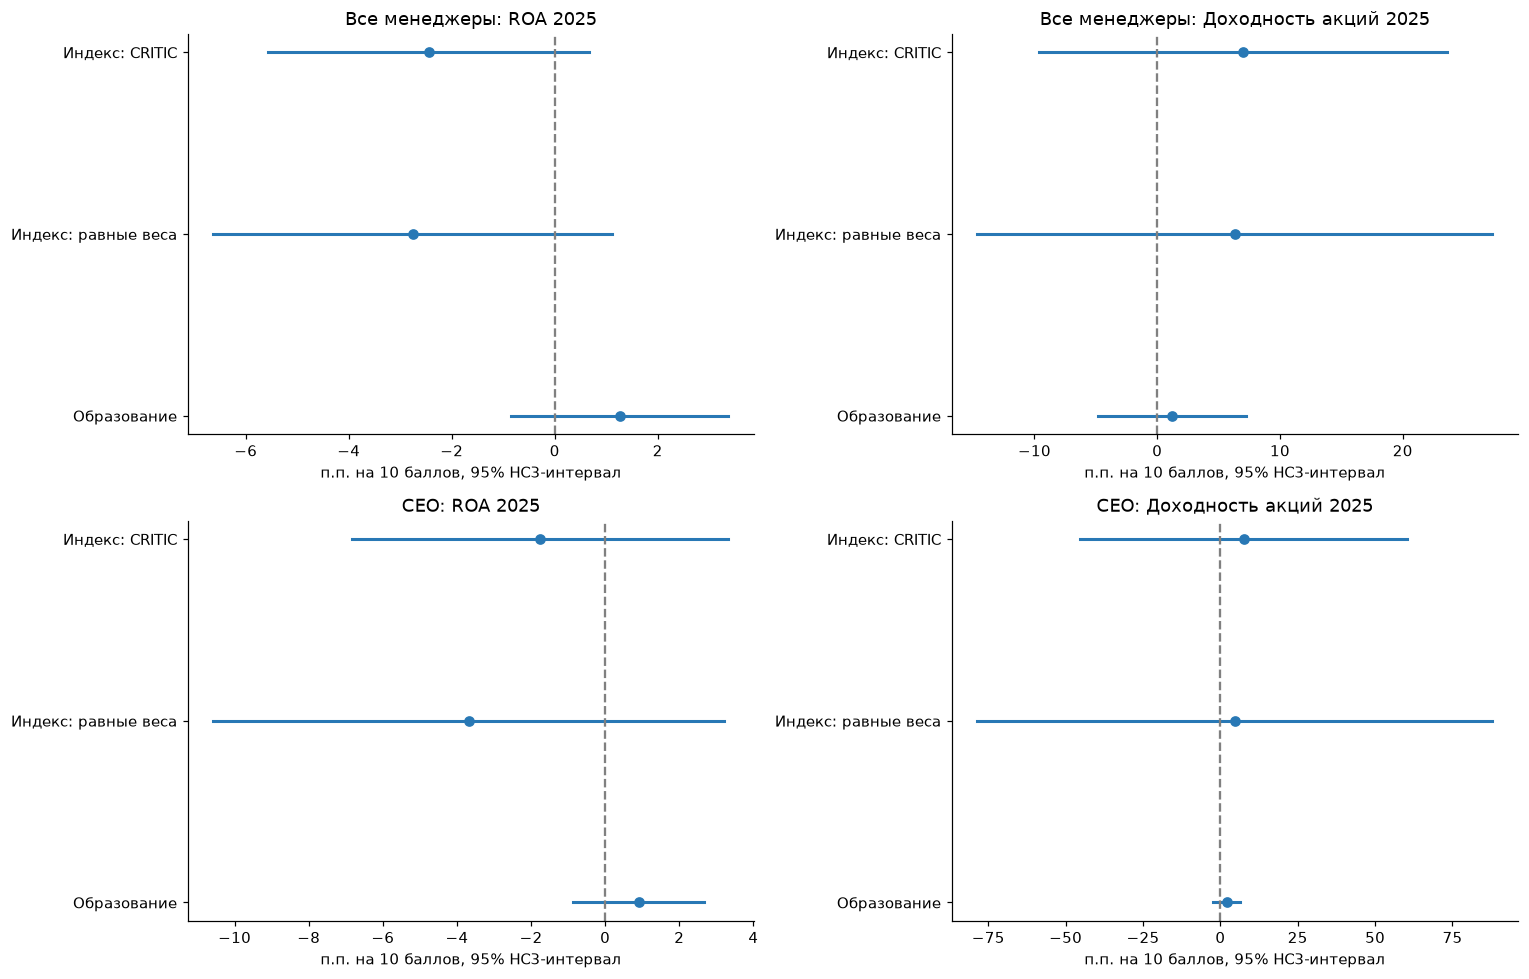

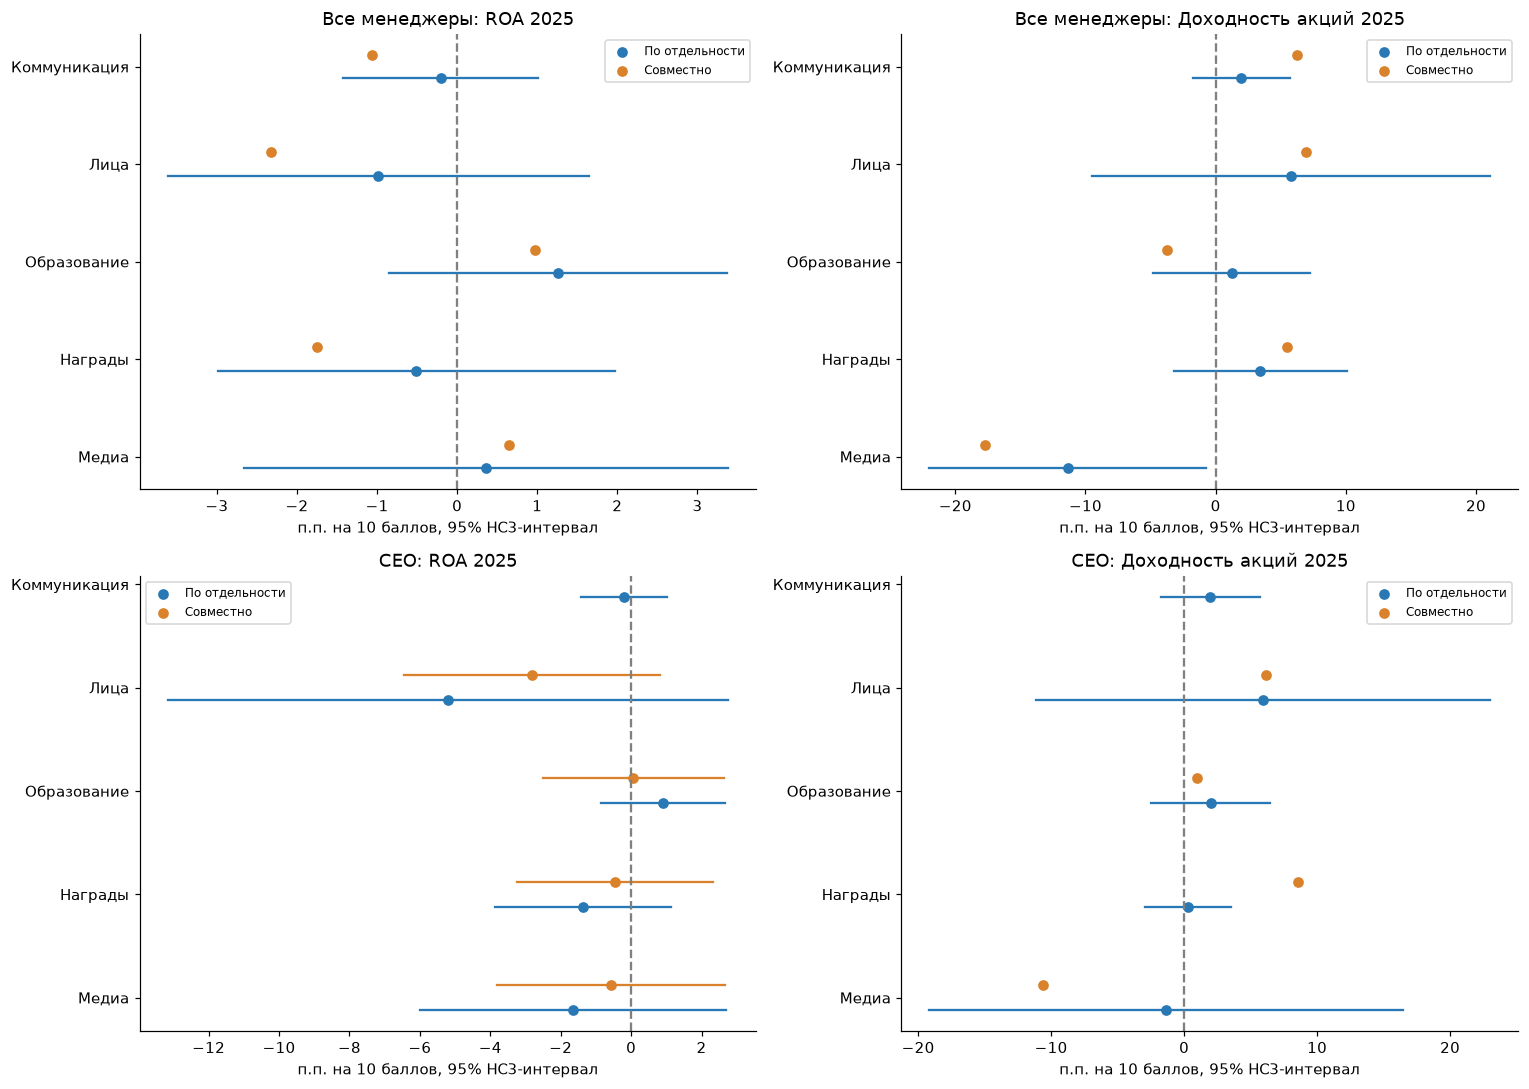

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, sample in enumerate(datasets):
    for col, outcome in enumerate(OUTCOMES):
        ax = axes[row, col]
        subset = primary[(primary['sample'] == sample) & (primary.outcome == outcome) & primary.block.ne('components_joint')]
        for i, (_, entry) in enumerate(subset.iterrows()):
            ax.plot([entry.ci_low_pp, entry.ci_high_pp], [i, i], color='#2878B5', lw=2)
            ax.scatter(entry.effect_pp_per_10_points, i, color='#2878B5')
        ax.axvline(0, color='gray', linestyle='--')
        ax.set(yticks=range(len(subset)), yticklabels=[LABELS[t.removesuffix('_10')] for t in subset.term],
               title=f'{SAMPLE_LABELS[sample]}: {OUTCOME_LABELS[outcome]}', xlabel='п.п. на 10 баллов, 95% HC3-интервал')
finish_figure(fig, 'primary_coefficients')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row, sample in enumerate(datasets):
    for col, outcome in enumerate(OUTCOMES):
        ax = axes[row, col]
        for offset, frame, color, label in [(-.12, individual, '#2878B5', 'По отдельности'),
                                            (.12, primary[primary.block.eq('components_joint')], '#D9822B', 'Совместно')]:
            subset = frame[(frame['sample'] == sample) & (frame.outcome == outcome)].set_index('term')
            for i, component in enumerate(COMPONENTS):
                if component + '_10' not in subset.index:
                    continue
                entry = subset.loc[component + '_10']
                ax.plot([entry.ci_low_pp, entry.ci_high_pp], [i + offset] * 2, color=color)
                ax.scatter(entry.effect_pp_per_10_points, i + offset, color=color, label=label if i == 0 else None)
        ax.axvline(0, color='gray', linestyle='--')
        ax.set(yticks=range(len(COMPONENTS)), yticklabels=[LABELS[c] for c in COMPONENTS],
               title=f'{SAMPLE_LABELS[sample]}: {OUTCOME_LABELS[outcome]}', xlabel='п.п. на 10 баллов, 95% HC3-интервал')
        ax.legend(fontsize=8)
finish_figure(fig, 'components_separate_and_joint')

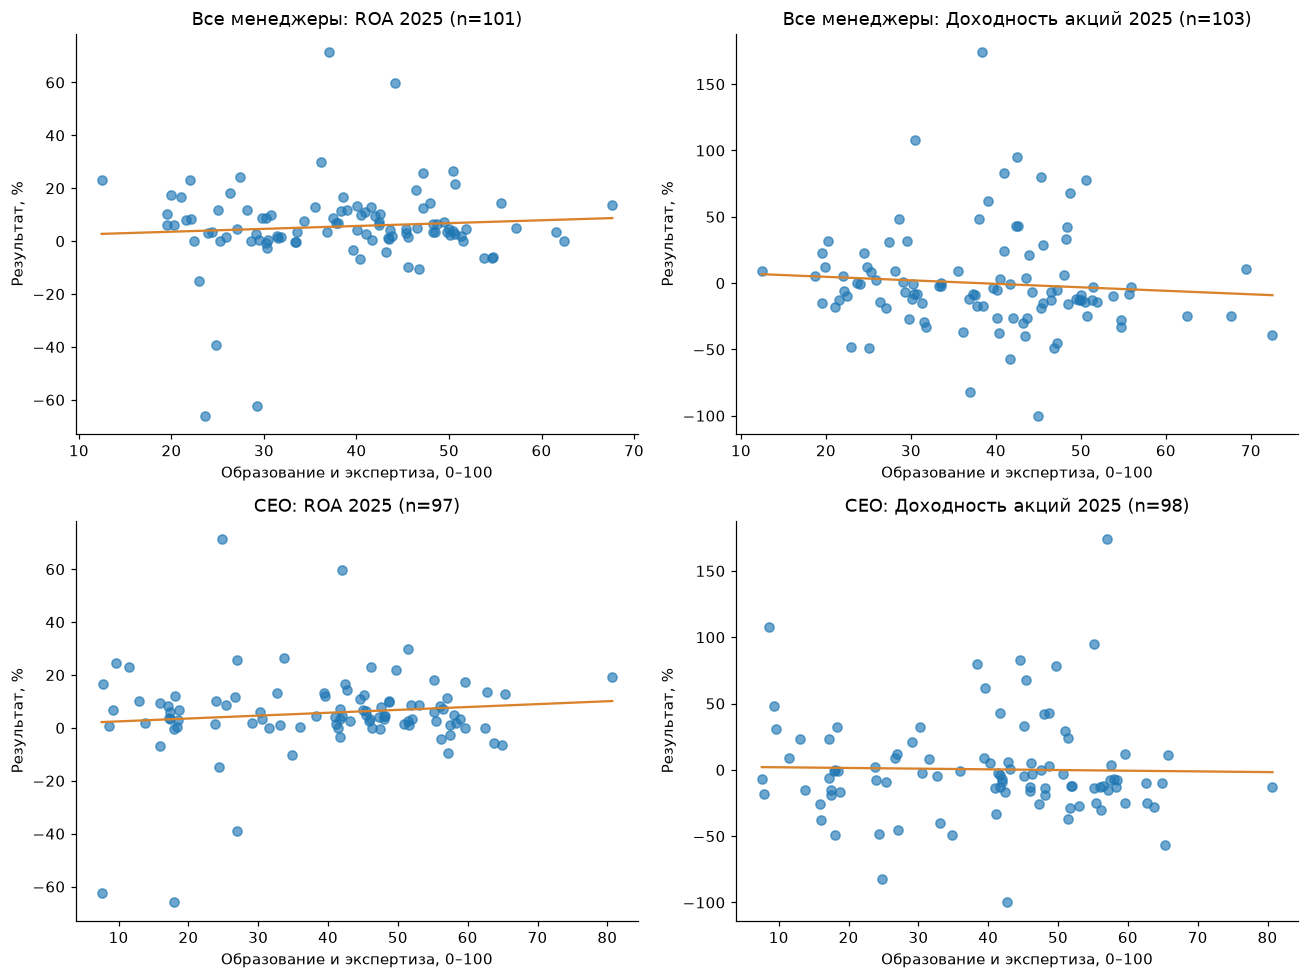

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row, sample in enumerate(datasets):
    for col, outcome in enumerate(OUTCOMES):
        ax = axes[row, col]
        pair = datasets[sample][['expertise_score', outcome]].dropna()
        ax.scatter(pair.expertise_score, 100 * pair[outcome], alpha=.65)
        if pair.expertise_score.nunique() > 1:
            b = np.polyfit(pair.expertise_score, 100 * pair[outcome], 1)
            grid = np.linspace(pair.expertise_score.min(), pair.expertise_score.max(), 100)
            ax.plot(grid, np.polyval(b, grid), color='#D9822B')
        ax.set(xlabel='Образование и экспертиза, 0–100', ylabel='Результат, %',
               title=f'{SAMPLE_LABELS[sample]}: {OUTCOME_LABELS[outcome]} (n={len(pair)})')
finish_figure(fig, 'education_finance_scatter')

## Дополнение: CatBoost–SHAP из исходного ноутбука

Повторяем дополнительный, обучаемый по ROA 2025, способ выбора внешних весов.
CatBoost: 500 итераций, глубина 3, learning rate 0.03, RMSE, seed 42.
Вес компоненты — её среднее абсолютное SHAP-значение, нормированное на сумму
по пяти компонентам. Контроли и отрасль входят в CatBoost, но не в сумму весов.
Это относительная предсказательная важность, а не знак или причинный эффект.

На общей ROA-выборке сравниваем модели OLS с контролями и отраслью; в каждом
LOOCV-повторе веса CatBoost обучаются **только на тренировочных компаниях**.
Сохраняются веса каждого повтора и фактические предсказания. Готовые CSV-индексы
в остальных моделях остаются фиксированными. Отраслевой дизайн фиксируется как
в исходнике; если исключение компании уменьшает ранг матрицы, предсказание
помечается неидентифицируемым и общий LOOCV не рассчитывается.

Как в поздней ячейке исходника, индекс с полными ROA-SHAP-весами также включается
в M3 для ROA и доходности. Его HC3/p-value **условны на оценённые веса** и не учитывают
их подбор по ROA; это исследовательское дополнение, не основной тест гипотез.
Блок можно отключить параметром `RUN_CATBOOST`.

In [9]:
catboost_comparisons, catboost_status = [], []
if RUN_CATBOOST:
    from catboost import CatBoostRegressor, Pool

    def cb_weights(train):
        features = [*COMPONENTS, 'roa_2024', *CONTROLS, 'industry_group']
        model = CatBoostRegressor(iterations=500, depth=3, learning_rate=.03, loss_function='RMSE',
                                  verbose=False, random_seed=SEED, thread_count=1, allow_writing_files=False)
        pool = Pool(train[features], train.roa_2025, cat_features=['industry_group'])
        model.fit(pool)
        shap = model.get_feature_importance(pool, type='ShapValues')[:, :-1]
        importance = pd.Series(np.abs(shap).mean(axis=0), index=features).reindex(COMPONENTS)
        if importance.sum() <= 0:
            raise ValueError('Нулевая SHAP-важность компонент')
        return importance / importance.sum()

    def checked_prediction(x_train, y_train, x_test):
        # Константы удаляются одинаково из train и test, кроме Intercept.
        keep = ['Intercept', *[c for c in x_train if c != 'Intercept' and x_train[c].nunique() > 1]]
        # Изменение постоянного предиктора на test не поддержано тренировочными данными.
        dropped = [c for c in x_train if c not in keep]
        if any(not np.isclose(x_test[c].iloc[0], x_train[c].iloc[0]) for c in dropped):
            raise ValueError('Неидентифицируемый уровень предиктора/отрасли в holdout')
        a, b = x_train[keep].to_numpy(float), x_test[keep].to_numpy(float)
        if np.linalg.matrix_rank(a) < a.shape[1] or len(a) <= a.shape[1] + 2:
            raise ValueError('Недостаточный ранг или размер train')
        return float((b @ np.linalg.lstsq(a, y_train.to_numpy(float), rcond=None)[0])[0])

    for sample, data in datasets.items():
        required = ['roa_2025', 'roa_2024', *CONTROLS, 'industry_group', *COMPONENTS, 'index_equal', 'index_critic']
        d = data.dropna(subset=required).copy()
        print(f'CatBoost–SHAP {sample}: {len(d)} LOOCV-повторов')
        full_weights = cb_weights(d)
        full_data = data.copy()
        full_data['index_catboost_10'] = full_data[COMPONENTS].dot(full_weights) / 10
        for outcome, lag in OUTCOMES.items():
            run_model(sample, full_data, outcome, 'index_catboost', 'M3',
                      ['index_catboost_10', lag, *CONTROLS], focal=['index_catboost_10'], family='catboost_exploratory')
        design = pd.get_dummies(d[['roa_2024', *CONTROLS, 'industry_group']], columns=['industry_group'], drop_first=True, dtype=float)
        design.insert(0, 'Intercept', 1.)
        specifications = {'controls': [], 'education': ['expertise_score'], 'index_equal': ['index_equal'],
                          'index_critic': ['index_critic'], 'components_joint': COMPONENTS, 'index_catboost': ['index_catboost']}
        d['index_catboost'] = d[COMPONENTS].dot(full_weights)
        predictions, fold_weights = [], []
        for i, ticker in enumerate(d.index):
            train, test = d.drop(index=ticker).copy(), d.loc[[ticker]].copy()
            fold_w = cb_weights(train)
            fold_weights.append({'held_out': ticker, 'n_train': len(train), **fold_w.to_dict()})
            for block, added in specifications.items():
                x_train, x_test = design.drop(index=ticker).copy(), design.loc[[ticker]].copy()
                for term in added:
                    if term == 'index_catboost':
                        x_train[term], x_test[term] = train[COMPONENTS].dot(fold_w), test[COMPONENTS].dot(fold_w)
                    else:
                        x_train[term], x_test[term] = train[term], test[term]
                reason, pred = '', np.nan
                try:
                    pred = checked_prediction(x_train, train.roa_2025, x_test)
                except ValueError as exc:
                    reason = str(exc)
                predictions.append({'ticker': ticker, 'block': block, 'actual': float(test.roa_2025.iloc[0]),
                                    'prediction': pred, 'reason': reason})
        folds, pred_table = pd.DataFrame(fold_weights).set_index('held_out'), pd.DataFrame(predictions)
        weight_summary = pd.DataFrame({'full_weight': full_weights, 'loo_mean': folds[COMPONENTS].mean(),
                                      'loo_std': folds[COMPONENTS].std(), 'loo_min': folds[COMPONENTS].min(), 'loo_max': folds[COMPONENTS].max()})
        for block, added in specifications.items():
            fit = fit_ols(d, 'roa_2025', ['roa_2024', *CONTROLS, *added], ['industry_group'])
            pred = pred_table[pred_table.block.eq(block)]
            sst = np.sum((d.roa_2025 - d.roa_2025.mean()) ** 2)
            valid = pred.prediction.notna().all()
            mse = np.mean((pred.actual - pred.prediction) ** 2) if valid else np.nan
            catboost_comparisons.append({'sample': sample, 'block': block, 'n': len(d), 'r2': fit['r2'],
                'adj_r2': fit['adj_r2'], 'loocv_r2': 1 - mse * len(d) / sst,
                'loocv_rmse': np.sqrt(mse), 'undefined_folds': int(pred.prediction.isna().sum())})
        save_table(folds, f'{sample}_catboost_fold_weights')
        save_table(pred_table, f'{sample}_catboost_loocv_predictions', index=False)
        save_table(weight_summary, f'{sample}_catboost_weight_stability')
        display(weight_summary.round(4))
        catboost_status.append({'sample': sample, 'status': 'executed', 'n': len(d)})
    catboost_comparisons = pd.DataFrame(catboost_comparisons)
    save_table(catboost_comparisons, 'catboost_comparison', index=False)
    display(catboost_comparisons.round(4))
else:
    catboost_status.append({'status': 'disabled_by_config'})

CatBoost–SHAP all_managers: 56 LOOCV-повторов


,full_weight,loo_mean,loo_std,loo_min,loo_max
media_score,0.2229,0.1820,0.0485,0.1205,0.3760
awards_score,0.4211,0.4076,0.0494,0.2511,0.5157
expertise_score,0.2399,0.2952,0.0432,0.2155,0.4613
face_score,0.1126,0.1135,0.0235,0.0741,0.1833
communication_score,0.0035,0.0016,0.0015,0.0000,0.0055


CatBoost–SHAP ceo: 27 LOOCV-повторов


,full_weight,loo_mean,loo_std,loo_min,loo_max
media_score,0.1726,0.2071,0.0578,0.0897,0.3647
awards_score,0.4913,0.4423,0.0894,0.0475,0.5574
expertise_score,0.1325,0.1466,0.0486,0.0738,0.2684
face_score,0.2036,0.2040,0.0697,0.0805,0.4952
communication_score,0.0000,0.0000,0.0000,0.0000,0.0000


,sample,block,n,r2,adj_r2,loocv_r2,loocv_rmse,undefined_folds
0,all_managers,controls,56,0.7109,0.6387,0.0635,0.1336,0
1,all_managers,education,56,0.7155,0.6361,0.0157,0.1370,0
2,all_managers,index_equal,56,0.7267,0.6504,0.1112,0.1302,0
3,all_managers,index_critic,56,0.7265,0.6502,0.1146,0.1299,0
4,all_managers,components_joint,56,0.7337,0.6244,NaN,NaN,1
5,all_managers,index_catboost,56,0.7250,0.6482,0.0804,0.1324,0
6,ceo,controls,27,0.9242,0.8686,NaN,NaN,3
7,ceo,education,27,0.9257,0.8620,NaN,NaN,3
8,ceo,index_equal,27,0.9419,0.8921,NaN,NaN,3
9,ceo,index_critic,27,0.9357,0.8805,NaN,NaN,3


## Диагностика, результаты и воспроизводимость

Основные результаты: `primary_M3_fdr.csv`, `individual_components_fdr.csv` и
`model_comparison_common_sample.csv`. Полные коэффициенты всех моделей,
включая дополнительные спецификации, сохраняются отдельно. Отрицательный LOOCV R²
означает, что ошибки больше SST относительно среднего фактического результата
на анализируемой выборке; высокая внутривыборочная R² сама по себе не подтверждает
предсказательное качество.

Проверка вариации ниже показывает число уникальных значений и минимальный размер
группы для дискретных компонент на каждой M3-выборке. В текущих данных коммуникация
в общей полной выборке равна 100 у всех, кроме POSI (0); в полной CEO-выборке
она постоянна. Для CEO и доходности 2025 только RENI имеет ненулевые награды.
Такие регрессоры дают h=1 либо неотличимы от константы. Точечные коэффициенты
сохраняются там, где идентифицированы, но неопределённые HC3/PRESS не заменяются
искусственными числами. Таблица вариации и список h≈1 экспортируются отдельно.

Здесь нет причинной идентификации и внешней проверки индекса: финансовые результаты
могут быть связаны с пропущенными характеристиками компаний. Небольшая полная
CEO-выборка особенно ограничивает модели с пятью компонентами и отраслевыми эффектами.
Внутренние и внешние веса готовых индексов трактуются как фиксированные;
HC3 не включает неопределённость их оценки.

In [10]:
models = pd.DataFrame(model_rows)
coefficients = pd.DataFrame(coefficient_rows)
save_table(models, 'all_model_diagnostics', index=False)
save_table(coefficients, 'all_coefficients', index=False)
save_table(pd.DataFrame(membership_rows), 'model_sample_membership', index=False)
save_table(pd.DataFrame(observation_rows), 'model_observations', index=False)
save_table(pd.DataFrame(catboost_status), 'catboost_status', index=False)
issues = models[models.status.ne('ok') | models.dropped_constant.fillna('').ne('')]
display(issues[['sample', 'outcome', 'block', 'specification', 'n', 'status', 'dropped_constant', 'reason']])
save_table(issues, 'model_issues', index=False)
variation_rows = []
for sample, data in datasets.items():
    for outcome, lag in OUTCOMES.items():
        complete = data.dropna(subset=[outcome, lag, *CONTROLS, *COMPONENTS])
        for component in COMPONENTS:
            counts = complete[component].value_counts()
            variation_rows.append({'sample': sample, 'outcome': outcome, 'component': component,
                'n': len(complete), 'unique_values': len(counts),
                'smallest_level_n': counts.min() if len(counts) <= 5 else np.nan,
                'level_counts': str(counts.to_dict()) if len(counts) <= 5 else ''})
variation = pd.DataFrame(variation_rows)
save_table(variation, 'joint_M3_component_variation', index=False)
display(variation[variation.unique_values.le(5)])
observations = pd.DataFrame(observation_rows)
save_table(observations[observations.leverage.ge(1 - 1e-10)], 'leverage_one_observations', index=False)

lines = []
for sample in datasets:
    lines.append('### ' + SAMPLE_LABELS[sample])
    for outcome in OUTCOMES:
        row = primary[(primary['sample'] == sample) & (primary.outcome == outcome) & primary.block.eq('education')].iloc[0]
        lines.append(f"{OUTCOME_LABELS[outcome]}, образование (M3): N={int(row.n)}, "
                     f"коэффициент {row.effect_pp_per_10_points:.3f} п.п. на 10 баллов, "
                     f"95% HC3-интервал [{row.ci_low_pp:.3f}; {row.ci_high_pp:.3f}], "
                     f"p={row.p_value:.4f}, BH q={row.q_value_bh:.4f}.")
    common = comparison[(comparison['sample'] == sample) & comparison.specification.eq('common_no_industry')]
    for outcome in OUTCOMES:
        part = common[common.outcome.eq(outcome)]
        valid = part.dropna(subset=['cv_r2'])
        if len(valid):
            best = valid.loc[valid.cv_r2.idxmax()]
            lines.append(f"Общая выборка {OUTCOME_LABELS[outcome]}: N={int(best.n_common)}; "
                         f"наибольший условный LOOCV R² у {best.block}: {best.cv_r2:.3f}.")
findings = '\n\n'.join(lines)
display(Markdown(findings))
(OUT / 'findings.md').write_text(findings + '\n', encoding='utf-8')
paths = [FINANCE_FILE, *INDEX_FILES.values(), *EDA_FILES.values(), *WEIGHT_FILES.values(), ROOT / 'utils/index_regression.py']
manifest = {'inputs': {str(path.relative_to(ROOT)): hashlib.sha256(path.read_bytes()).hexdigest() for path in paths},
    'controls': CONTROLS, 'outcomes': OUTCOMES, 'blocks': BLOCKS, 'covariance': 'HC3',
    'inference': 'Student t, df=N-rank', 'winsorization': [.01, .99], 'catboost_enabled': RUN_CATBOOST,
    'seed': SEED, 'catboost_parameters': {'iterations': 500, 'depth': 3, 'learning_rate': .03, 'loss': 'RMSE'},
    'cv_scope': 'fixed CSV indices; only CatBoost outer weights are refitted inside its LOOCV',
    'versions': {'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__, 'scipy': scipy.__version__}}
if RUN_CATBOOST:
    manifest['versions']['catboost'] = __import__('catboost').__version__
(OUT / 'manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
print('Результаты:', OUT)
print('PDF:', FIGS / 'index_regression_*.pdf')

,sample,outcome,block,specification,n,status,dropped_constant,reason
23,all_managers,roa_2025,components_joint,M3,56,undefined_hc3_and_press_leverage_one,,
24,all_managers,roa_2025,components_joint,M4,56,undefined_hc3_and_press_leverage_one,,
25,all_managers,roa_2025,components_joint,M5,38,undefined_hc3_and_press_leverage_one,,
26,all_managers,roa_2024,components_joint,C2024,56,undefined_hc3_and_press_leverage_one,,
27,all_managers,roa_2025_w,components_joint,W2025,56,undefined_hc3_and_press_leverage_one,,
31,all_managers,stock_return_2025,education,M4,77,undefined_hc3_and_press_leverage_one,,
38,all_managers,stock_return_2025,index_equal,M4,43,undefined_hc3_and_press_leverage_one,,
45,all_managers,stock_return_2025,index_critic,M4,43,undefined_hc3_and_press_leverage_one,,
51,all_managers,stock_return_2025,components_joint,M3,43,undefined_hc3_and_press_leverage_one,,
52,all_managers,stock_return_2025,components_joint,M4,43,undefined_hc3_and_press_leverage_one,,


,sample,outcome,component,n,unique_values,smallest_level_n,level_counts
4,all_managers,roa_2025,communication_score,56,2,1.0,"{100.0: 55, 0.0: 1}"
9,all_managers,stock_return_2025,communication_score,43,2,1.0,"{100.0: 42, 0.0: 1}"
11,ceo,roa_2025,awards_score,27,4,1.0,"{0.0: 22, 22.7670248696953: 2, 52.863394681944..."
14,ceo,roa_2025,communication_score,27,1,27.0,{100.0: 27}
16,ceo,stock_return_2025,awards_score,20,2,1.0,"{0.0: 19, 52.8633946819448: 1}"
19,ceo,stock_return_2025,communication_score,20,1,20.0,{100.0: 20}


### Все менеджеры

ROA 2025, образование (M3): N=93, коэффициент 1.259 п.п. на 10 баллов, 95% HC3-интервал [-0.853; 3.372], p=0.2393, BH q=0.4785.

Доходность акций 2025, образование (M3): N=77, коэффициент 1.230 п.п. на 10 баллов, 95% HC3-интервал [-4.806; 7.266], p=0.6855, BH q=0.6855.

Общая выборка ROA 2025: N=56; наибольший условный LOOCV R² у index_critic: 0.479.

Общая выборка Доходность акций 2025: N=43; наибольший условный LOOCV R² у controls: 0.229.

### CEO

ROA 2025, образование (M3): N=90, коэффициент 0.906 п.п. на 10 баллов, 95% HC3-интервал [-0.865; 2.677], p=0.3120, BH q=0.7186.

Доходность акций 2025, образование (M3): N=74, коэффициент 1.985 п.п. на 10 баллов, 95% HC3-интервал [-2.514; 6.484], p=0.3816, BH q=0.7186.

Общая выборка ROA 2025: N=27; наибольший условный LOOCV R² у controls: 0.806.

Общая выборка Доходность акций 2025: N=20; наибольший условный LOOCV R² у controls: -2.809.

Результаты: /Users/mac/Reputation project/results/index_regression
PDF: /Users/mac/Reputation project/figs/index_regression_*.pdf
